In [1]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from utils.plotting import (
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
    LW_FINE, LW_GUIDE, NEUTRAL_COLOR, PRIMARY_COLOR,
    SCATTER_S_FINE,
)


In [2]:
DATA_DIR = Path('../../data/lab03/m17_calibration')

paths = sorted(DATA_DIR.glob('*.npz'))
files = [np.load(p) for p in paths]
print(f'Loaded {len(files)} captures from {DATA_DIR.resolve()}')

f0       = files[0]
F_S_HZ   = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_CH     = int(f0['corr'].shape[0])
N_FFT    = int(f0['n_fft'])       if 'n_fft'    in f0 else 2048
DF_HZ    = F_S_HZ / N_FFT

# Sky-frequency axis for all 1024 channels (SNAP 2048-pt real FFT)
# f_sky(k) = F_RF0 + k * F_S/N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

# Global peak amplitude (excluding DC ch 0) — used to normalise all spectra
all_amp   = np.array([np.abs(f['corr']) for f in files])  # (N, N_CH)
all_amp[:, 0] = 0.0                                        # zero DC
AMP_PEAK  = all_amp.max()

print(f'Band       : {F_SKY_GHZ[1]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  '
      f'({DF_HZ/1e3:.1f} kHz/ch, {N_CH} ch)')
print(f'Global peak: {AMP_PEAK:.4f}  (used for normalisation)')


Loaded 34 captures from /Users/junruiting/GitHub/ay-121/data/lab03/m17_calibration
Band       : 9.7902 -- 10.0398 GHz  (244.1 kHz/ch, 1024 ch)
Global peak: 0.9051  (used for normalisation)


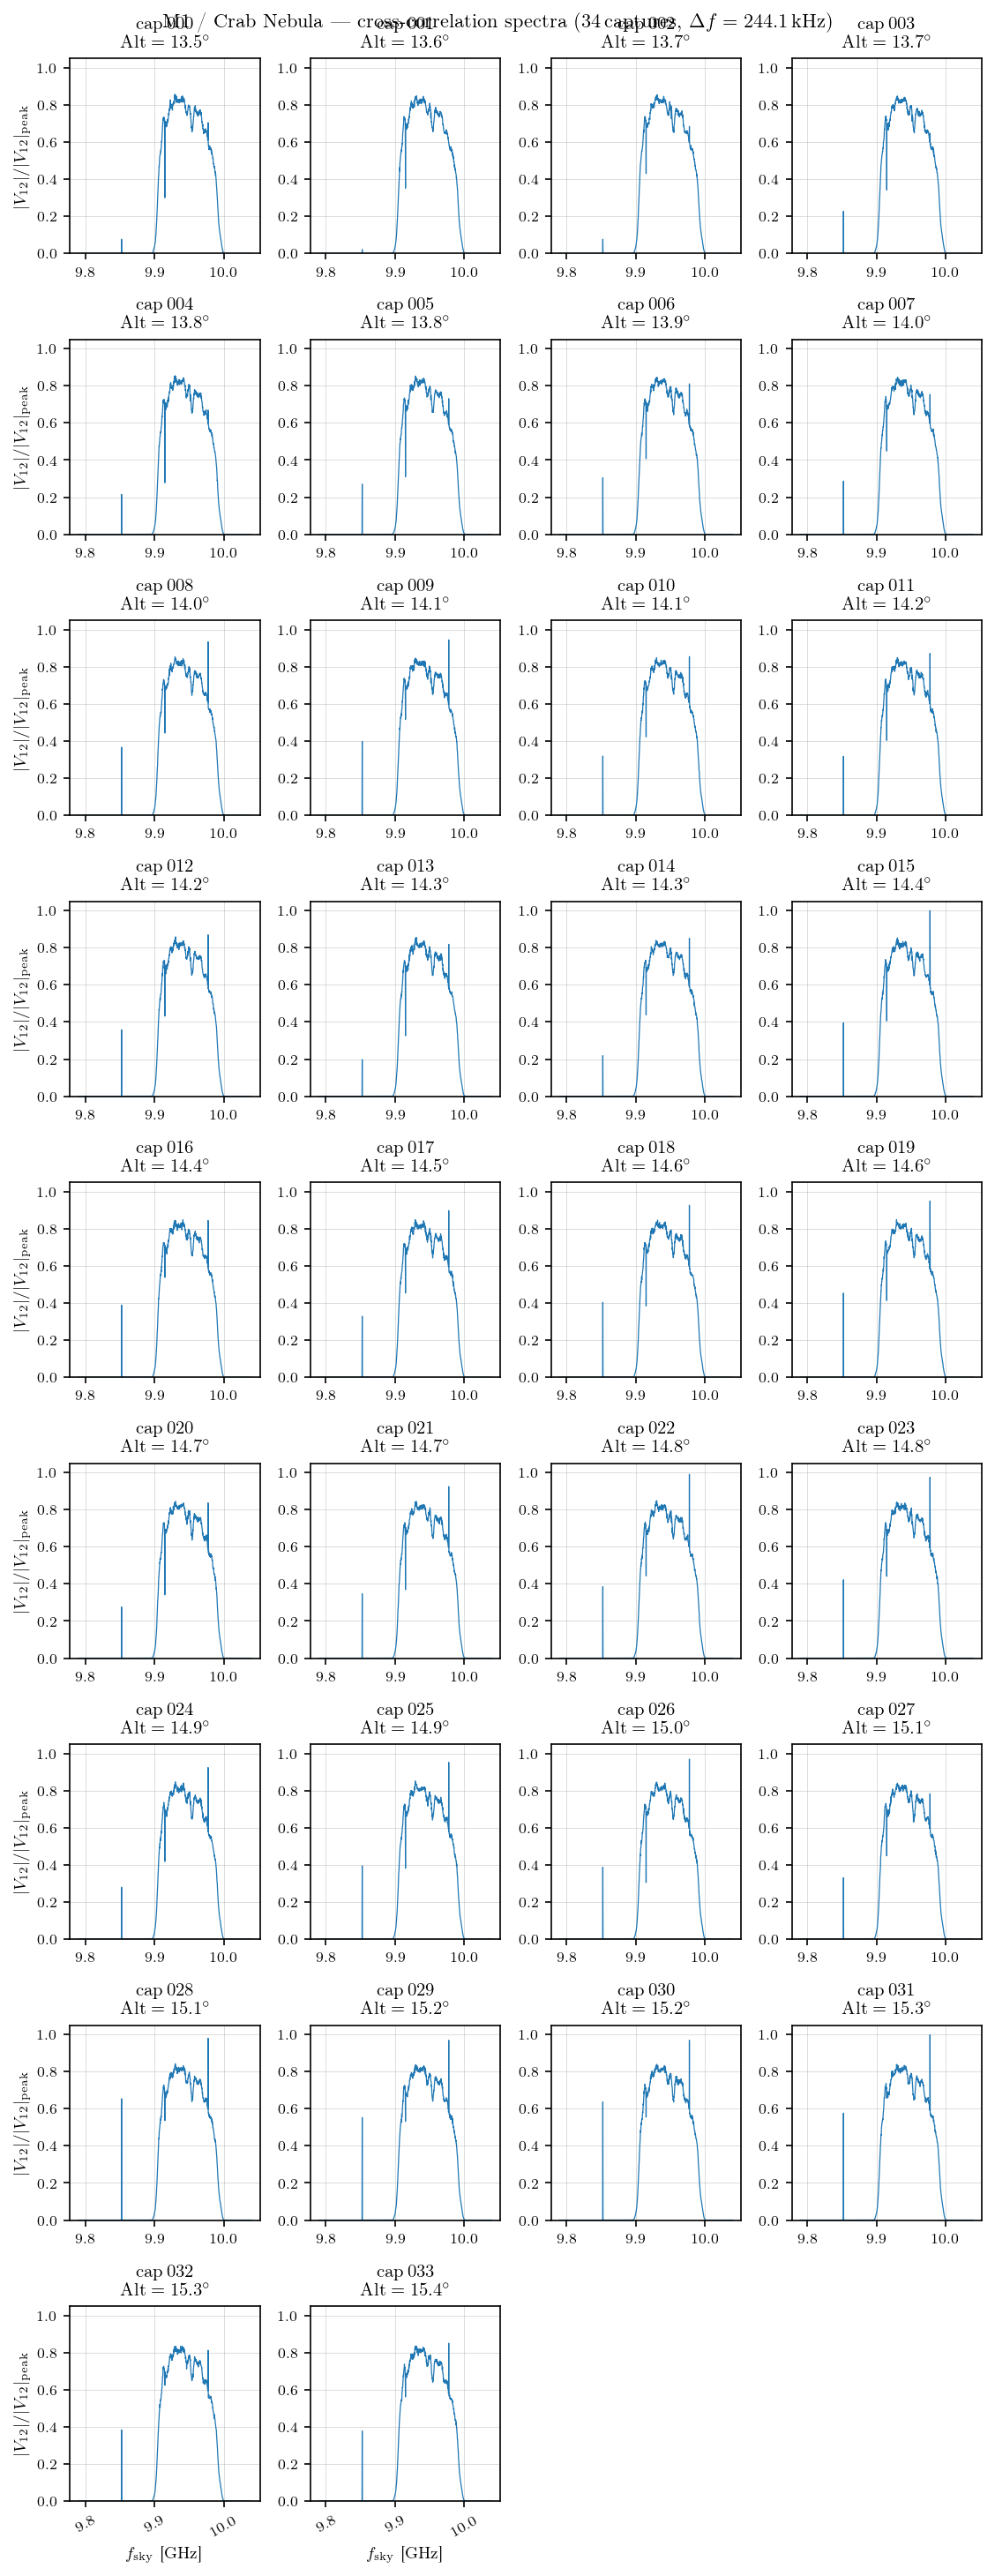

In [3]:
n     = len(files)
NCOLS = 4
nrows = int(np.ceil(n / NCOLS))

fig, axes = plt.subplots(
    nrows, NCOLS,
    figsize=(TEXTWIDTH_IN, 2.2 * nrows),
)
axes_flat = np.array(axes).flatten()

for i, f in enumerate(files):
    ax  = axes_flat[i]
    amp = np.abs(f['corr']).astype(float) / AMP_PEAK   # dimensionless in [0, 1]
    amp[0] = np.nan                                     # mask DC / LO

    ax.plot(F_SKY_GHZ, amp, lw=LW_FINE, color=PRIMARY_COLOR)

    t_str = paths[i].stem.split('_corr_')[-1]          # timestamp from filename
    ax.set_title(
        rf'\textrm{{cap\,{i:03d}}}' + '\n' +
        rf'$\mathrm{{Alt}}={float(f["alt_deg"]):.1f}^{{\circ}}$',
    )

    if i % NCOLS == 0:
        ax.set_ylabel(r'$|V_{12}| / |V_{12}|_{\rm peak}$')
    if i >= (nrows - 1) * NCOLS:
        ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
        ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y')
    ax.set_ylim(0, 1.05)

# Hide unused axes
for ax in axes_flat[n:]:
    ax.set_visible(False)

fig.suptitle(
    rf'M1 / Crab Nebula --- cross-correlation spectra '
    rf'({n}\,captures, $\Delta f={DF_HZ/1e3:.1f}$\,kHz)',
)
fig.tight_layout()
plt.show()


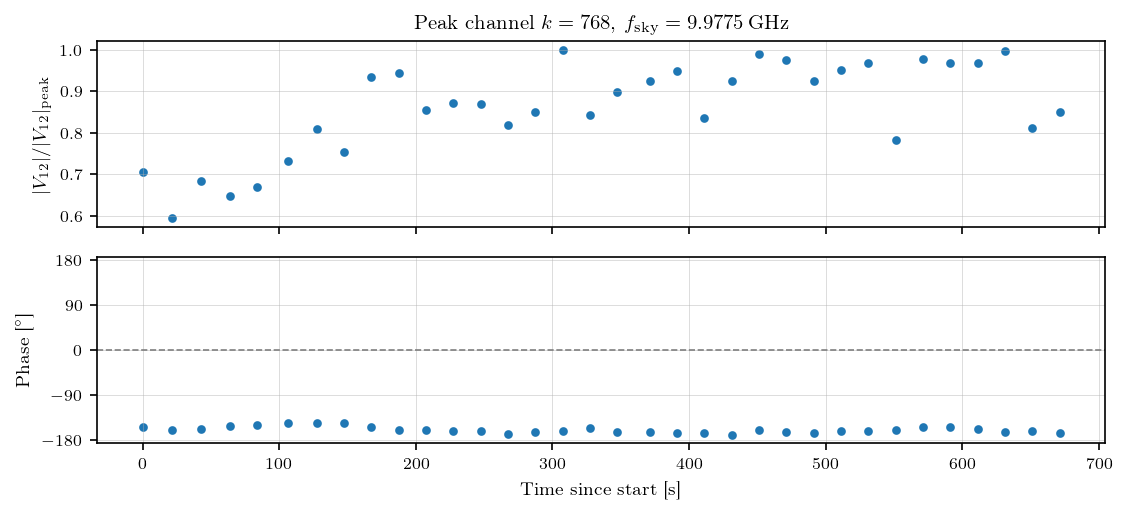

Peak channel : k=768,  f_sky=9.9775 GHz
Amp  (norm)  : mean=0.861,  std=0.110
Phase        : mean=-159.1°,  std=6.4°


In [4]:
# Sort by unix_time so the time-series is in order
times = np.array([float(f['unix_time']) for f in files])
order = np.argsort(times)
times_sorted = times[order]
t_rel = times_sorted - times_sorted[0]       # seconds since first capture

k_peak = int(np.argmax(all_amp.mean(axis=0)))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak   = np.array([files[j]['corr'][k_peak] for j in order])
amp_peak   = np.abs(vis_peak) / AMP_PEAK
phase_peak = np.rad2deg(np.angle(vis_peak))

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 3.5), sharex=True)

axes[0].scatter(t_rel, amp_peak, s=SCATTER_S_FINE, color=PRIMARY_COLOR)
axes[0].set_ylabel(r'$|V_{12}| / |V_{12}|_{\rm peak}$')
axes[0].set_title(
    rf'Peak channel $k={k_peak}$,\ '
    rf'$f_{{\rm sky}}={F_PEAK_GHZ:.4f}$\,GHz',
)

axes[1].scatter(t_rel, phase_peak, s=SCATTER_S_FINE, color=PRIMARY_COLOR)
axes[1].axhline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--')
axes[1].set_ylabel(r'Phase [$^{\circ}$]')
axes[1].set_xlabel(r'Time since start [s]')
axes[1].set_ylim(-185, 185)
axes[1].set_yticks([-180, -90, 0, 90, 180])

fig.tight_layout()
plt.show()

print(f'Peak channel : k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')
print(f'Amp  (norm)  : mean={amp_peak.mean():.3f},  std={amp_peak.std():.3f}')
print(f'Phase        : mean={phase_peak.mean():.1f}°,  std={phase_peak.std():.1f}°')
